<a href="https://colab.research.google.com/github/MAvRK7/Neural-Nets-Learning/blob/main/Makemore5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wavenet

Prev we have built an MLP which takes 3 inputs and predicts the output (char level). 1 hidden layer, tanh non-linearity

Now, we will complex-ify:
* take more chars (more than 3 in a seq as input)
* Not feed them all into a single hidden layer (too much info squash too quickly)
* want to make a deeper model that progressively fuses this info to make its guess about the next char

This will look like "Wavenet"- a paper publsihed by Deepmind in 2016 https://arxiv.org/pdf/1609.03499 - it tries to predict audio sequences (not chars)

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [ ]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [ ]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
#basically this layer has state "training ON/OFF", and state is NOT good
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      # if its 2D, 0th dim - batch size, 1st dim - emb
      if x.ndim == 2:
        dim = 0 #take mean/var along 0 (batch-wise mean/var)
      #if its 3D (Used Later)
      elif x.ndim == 3: #0th: batch, 1st: token size, 2nd: emb dim
        dim = (0,1) #calc mean/var for all batches and all tokens
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [ ]:
torch.manual_seed(42); # seed rng for reproducibility

In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
C = torch.randn((vocab_size, n_embd))
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb]
  x = emb.view(emb.shape[0], -1) # flatten to 2D
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) #loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2966
  10000/ 200000: 2.2322
  20000/ 200000: 2.4111
  30000/ 200000: 2.1004
  40000/ 200000: 2.3157
  50000/ 200000: 2.2104
  60000/ 200000: 1.9653
  70000/ 200000: 1.9767
  80000/ 200000: 2.6738
  90000/ 200000: 2.0837
 100000/ 200000: 2.2730
 110000/ 200000: 1.7491
 120000/ 200000: 2.2891
 130000/ 200000: 2.3443
 140000/ 200000: 2.1731
 150000/ 200000: 1.8246
 160000/ 200000: 1.7614
 170000/ 200000: 2.2419
 180000/ 200000: 2.0803
 190000/ 200000: 2.1326


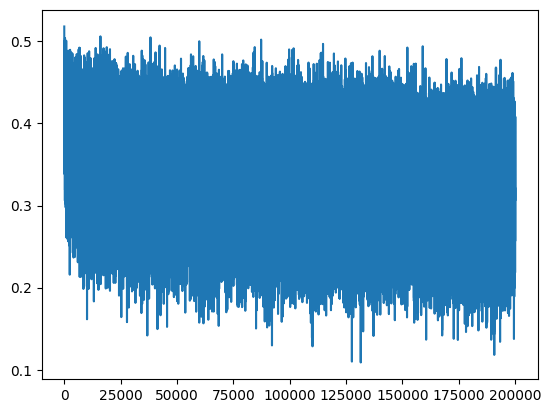

In [ ]:
plt.plot(lossi)

In [ ]:
# put layers into eval mode (needed for batchnorm especially)
for layer in layers:
  layer.training = False

In [ ]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # N, block_size, n_embd
  x = emb.view(emb.shape[0], -1) #concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0583250522613525
val 2.1065292358398438


In [ ]:
# sample from the model
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

ivon.
fanili.
thoommara.
kelo.
matyn.
leandr.
aleigh.
koldeniah.
prus.
carleen.
jah.
jorra.
alaya.
shonan.
vishylaharia.
juna.
vio.
orven.
mina.
laylee.


Lets fix the graph

In [ ]:
lossi[:10]

[0.5180676579475403,
 0.5164594054222107,
 0.507362961769104,
 0.507546603679657,
 0.4992470443248749,
 0.5014019012451172,
 0.5049523115158081,
 0.48866209387779236,
 0.4999050199985504,
 0.4899313449859619]

lets view lossi as 1000 of them per row (consecutive), and then take the mean

In [ ]:
torch.tensor(lossi).view(-1,1000).shape

torch.Size([200, 1000])

In [ ]:
torch.tensor(lossi).view(-1,1000).mean(1).shape

torch.Size([200])

If we plot this, it will be smoother

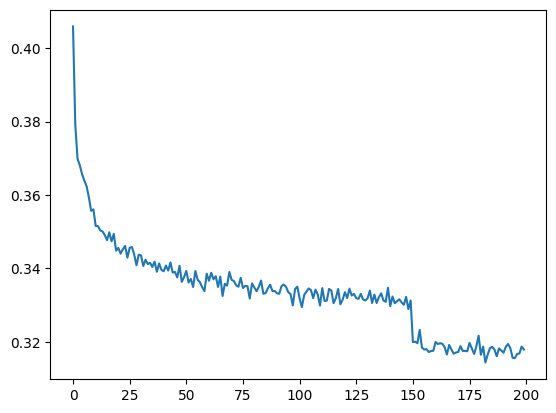

In [ ]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

That sharp dip was the lr decay

Now, lets fix the fwd pass

create modules for
1. embedding
2. flatenning (concat)

right now they're outside

In [ ]:
# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX): #does indexing in fwd pass
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class Flatten:

  def __call__(self, x): #does flatenning in fwd
    self.out = x.view(x.shape[0],-1)
    return self.out

  def parameters(self):
    return []

In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

#No need C = torch.randn((vocab_size, n_embd))
layers = [
    #instead of C
    Embedding(vocab_size,n_embd ),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = [p for layer in layers for p in layer.parameters()] # C is removed
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass

  # no need outside
  # emb = C[Xb]
  # x = emb.view(emb.shape[0], -1) # flatten to 2D
  x = Xb
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) #loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  break

      0/ 200000: 3.2962
  10000/ 200000: 1.9688
  20000/ 200000: 2.4812
  30000/ 200000: 2.0476
  40000/ 200000: 2.3654
  50000/ 200000: 2.1314
  60000/ 200000: 2.1536
  70000/ 200000: 1.7343
  80000/ 200000: 2.3771
  90000/ 200000: 1.8891
 100000/ 200000: 2.1398
 110000/ 200000: 2.1497
 120000/ 200000: 2.1139
 130000/ 200000: 2.0284
 140000/ 200000: 2.2514
 150000/ 200000: 2.1838
 160000/ 200000: 2.2758
 170000/ 200000: 2.3059
 180000/ 200000: 2.2483
 190000/ 200000: 1.9229


Great, but this is still bad, its all open

In [ ]:
'''
layers = [
    #instead of C
    Embedding(vocab_size,n_embd ),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]
'''

'\nlayers = [\n    #instead of C\n    Embedding(vocab_size,n_embd ),\n    Flatten(),\n    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),\n    Linear(n_hidden, vocab_size),\n]\n'

So can clean this by introducing containers- a way of organizing layers into lists or dicts

It basically passes a given input to all the layers sequentially

In [ ]:
# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class Flatten:

  def __call__(self, x):
    self.out = x.view(x.shape[0],-1)
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:

  # we pass in layers
  def __init__(self, layers):
    self.layers = layers

  #given any input in fwd pass
  def __call__(self, x):
    for layer in self.layers:
      # we call the layers sequentially
      x = layer(x)
    self.out = x
    # and return the result
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
#same
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

#NEW
# We make "model" and pass all the layers to it sequentially
model = Sequential(layers = [
    Embedding(vocab_size,n_embd ),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters() # NEW!, the parameters are of the model
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  #NEW: Logits is the model's output instead of x = Xb (input is Xb only)
  #outputs of the model
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) #loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.6215
  10000/ 200000: 2.2939
  20000/ 200000: 2.2842
  30000/ 200000: 2.6346
  40000/ 200000: 2.2827
  50000/ 200000: 2.0771
  60000/ 200000: 2.6391
  70000/ 200000: 2.3660
  80000/ 200000: 1.9311
  90000/ 200000: 2.9039
 100000/ 200000: 2.0171
 110000/ 200000: 2.1437
 120000/ 200000: 1.9909
 130000/ 200000: 2.4666
 140000/ 200000: 2.2137
 150000/ 200000: 2.2134
 160000/ 200000: 2.0766
 170000/ 200000: 2.5829
 180000/ 200000: 2.2428
 190000/ 200000: 2.0035


In [ ]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.062039613723755
val 2.106971502304077


In [ ]:
# sample from the model
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

zuri.
sio.
marque.
larianny.
dai.
pentie.
elie.
azaviannimir.
irynleed.
tymai.
evieh.
haylianna.
dai.
tavion.
mya.
mud.
oshte.
tamiya.
azeyan.
wathenlah.


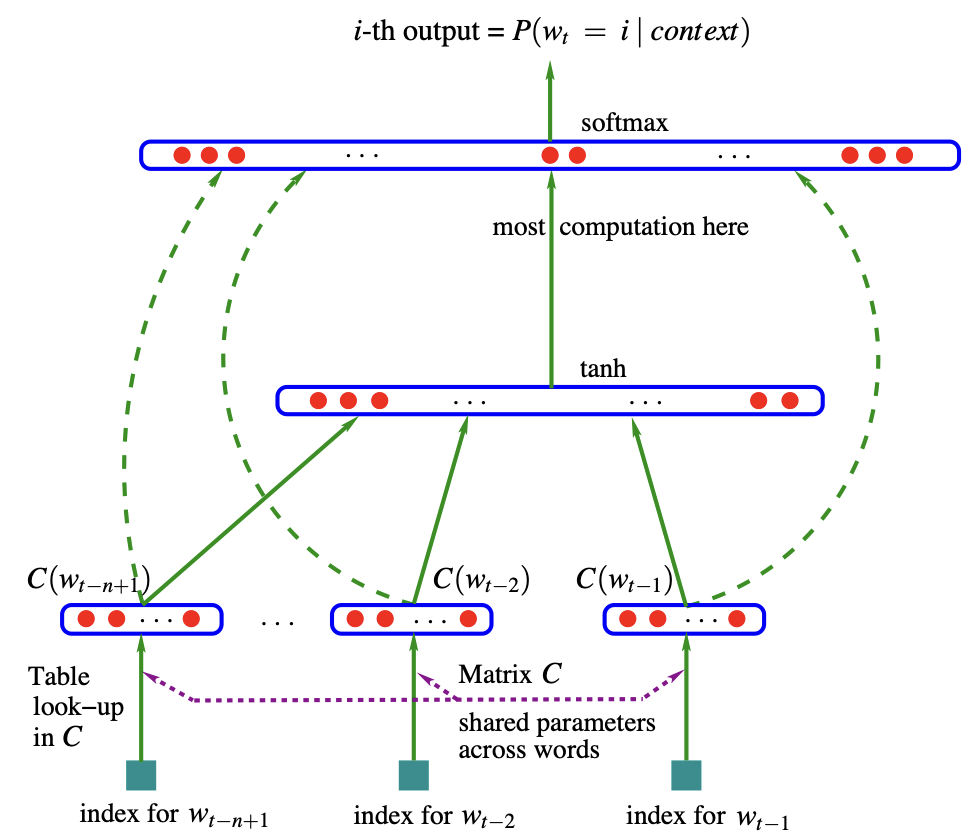

Now, we are using the Bengio arch- taking some chars, one hidden layer and then predicting the next char

We are crushing everything into 1 hidden layer at the beginning. Too much info squashed too soon (single step)

We want to move towards a wavenet

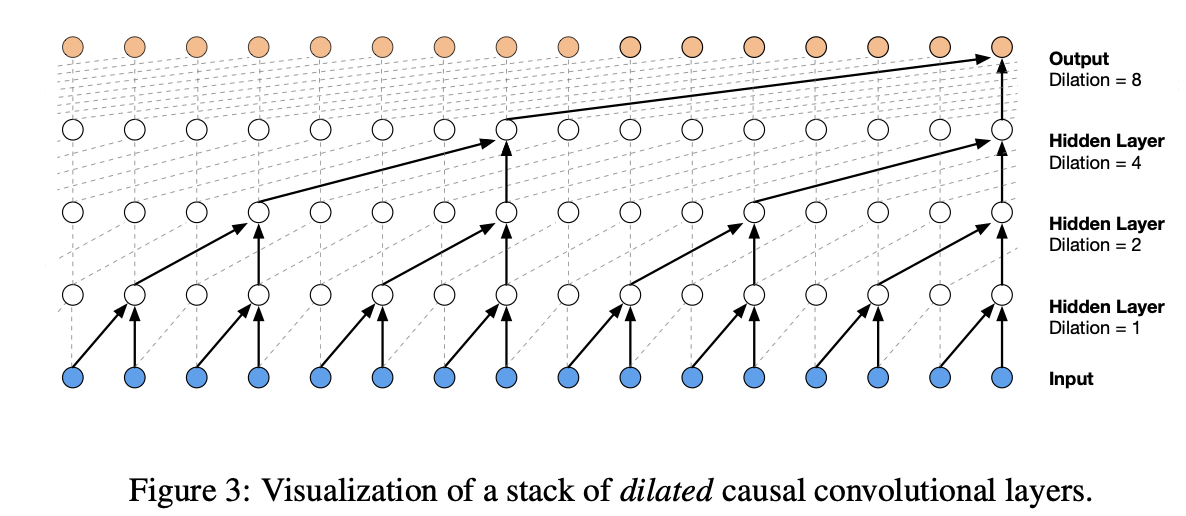

Everything does not get squashed into 1 layer, they are crushed slowly.

We take 2 chars and we fuse them (like a bigram- 2 input what next?). We do this for all chars consecutively. Then we take the bigrams, and we fuse those (4 char lvl chunks). Then we fuse that again. Tree like hierarchical way.

Slow fusing as it gets deeper. At each lvl, we fuse 2 thing: 2 chars, then 2 bigrams..etc

In [ ]:
# build the dataset
block_size = 8 # Its 8 now- context length: how many characters do we take to predict the next one?
# we take 8 chars now to predict the 9th
def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [ ]:
#same
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

model = Sequential(layers = [
    Embedding(vocab_size,n_embd ),
    Flatten(),
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22097


10k more parameters

In [ ]:
#explore the dataset, 4 random examples
ix = torch.randint(0, Xtr.shape[0],(4,))
Xb, Yb = Xtr[ix],Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  0, 19, 21],
        [ 0,  0,  0,  0,  0,  0,  1, 25],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])

Imagine this is the dataset for now ^

In [ ]:
#output of embedding layer
model.layers[0].out.shape

torch.Size([4, 8, 10])

So all of these numbers in Xb are transformed into 10 dim vectors

4 is the batch size, 8 is the block size, and 10 is the n_embd

8*10 catenation

In [ ]:
#output of the Flatten layer
model.layers[1].out.shape

torch.Size([4, 80])

In [ ]:
#linear layer output
# (4,80) @ (80,200) + (200)
model.layers[2].out.shape

torch.Size([4, 200])

---Diversion---

@ can multiply many different

In [ ]:
(torch.randn(10,20,80) @ torch.randn(80,200)).shape #we can add how many ever numbers before 80
# it will work

torch.Size([10, 20, 30, 200])

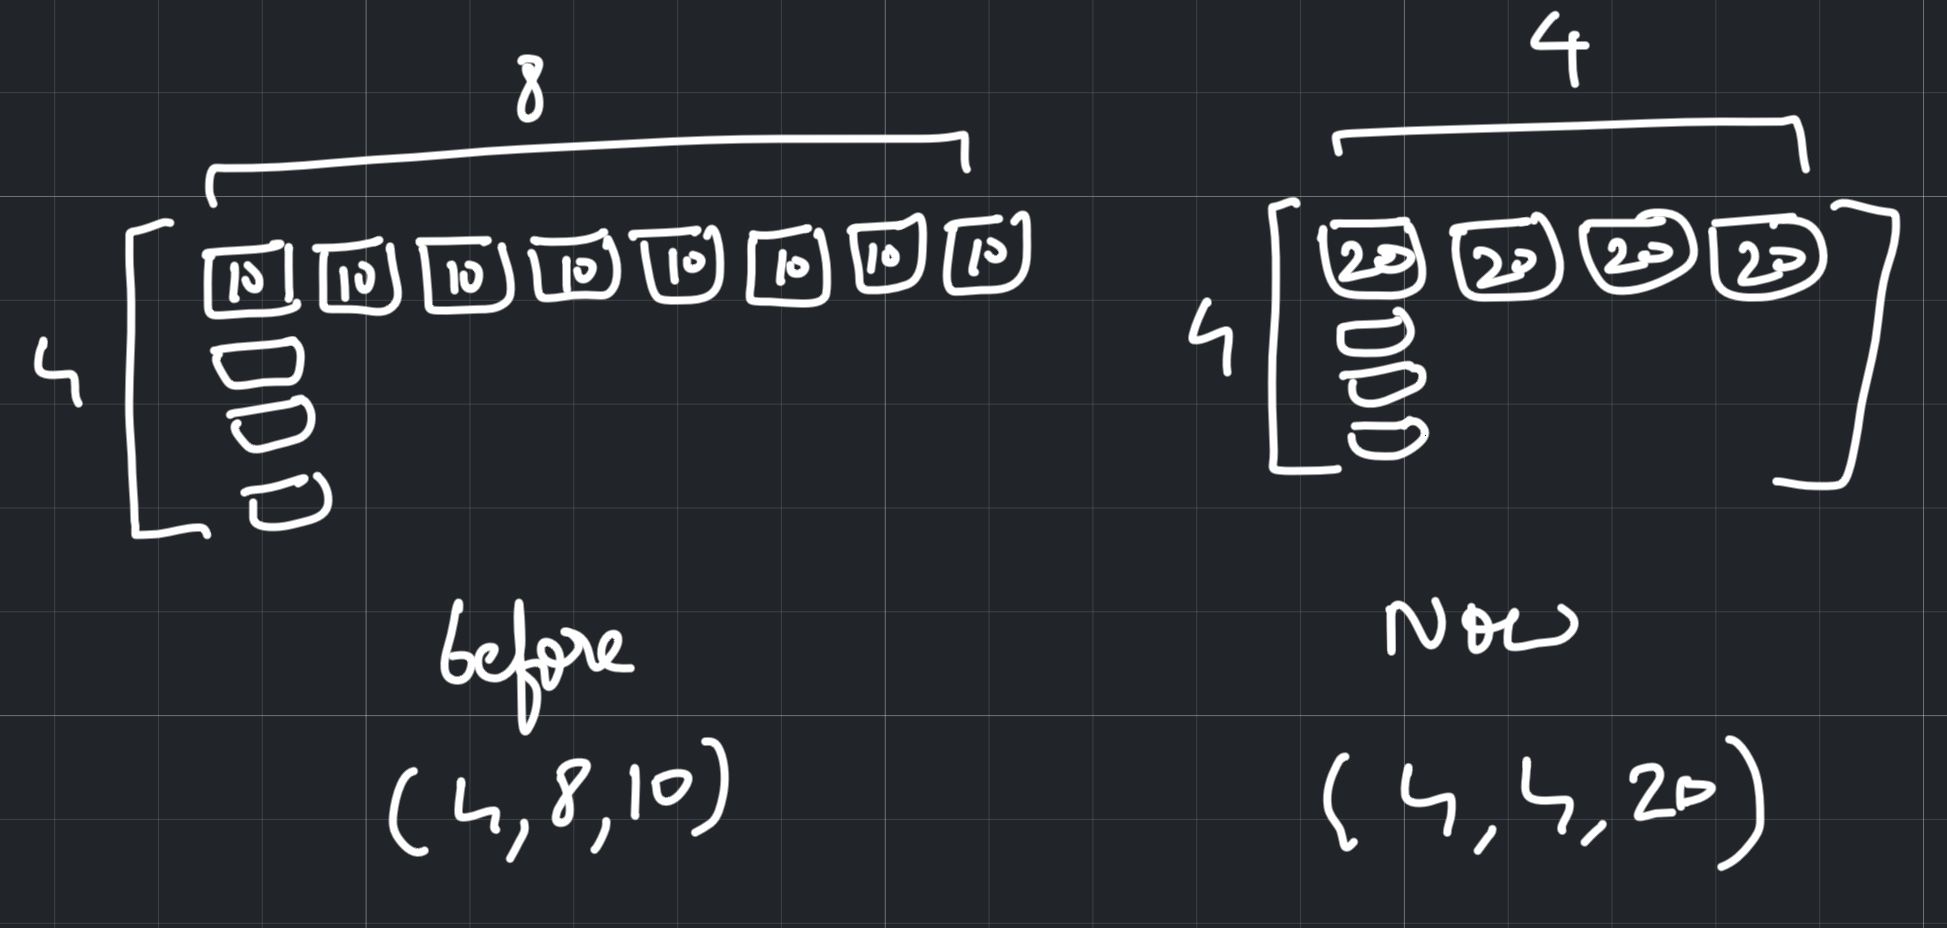

so right now # (4,80) @ (**80**,200) + (200)

80 chars come in the first layer, we dont want that now, we want 2. And those 2 chars should be fused

As each char becomes 10, we want 20 to come in

and here (4,**80**) @ (80,200) + (200)

We dont want 80 to come in, we want 2 to come in, 4,4,20. 4 groups of 2, each is 10

we dont want 1 2 3 4 5 6 7 8

we want (1 2) (3 4) (5 6) (7 8)

There are 4 of (), we want 2 and we want W to get multiplied with each ()

And in the output we dont want [4,80], we want [4,4,20]

the 1st 4 -> first batch dim (we want 4 egs)

2nd 4 -> 4 of ()s

In [ ]:
# this is what we want to get to

(torch.randn(4,4,20) @ torch.randn(20,200)+torch.randn(200)).shape

torch.Size([4, 4, 200])

Currently, the linear layer expects 80 nos. it should expect 20

And, the flatten layer should not create [40,80], but it should create [4,4,80]

So rn, we have a [4,8,10] input that feeds into the flatten, and the flatten stretches it out

it does (0,-1) or (4 and whatever is left) ie (4,8*10) => (4,80)

instead, we want it to be [4,4,20]

---Insight---

In [ ]:
print(f"Type of model.layers: {type(model.layers)}")
print(f"Length of model.layers (number of individual layers): {len(model.layers)}")

Type of model.layers: <class 'list'>
Length of model.layers (number of individual layers): 6


In [ ]:
# To show the output shape of each layer, we first need to perform a forward pass
# We'll use a small dummy batch of input data for demonstration.

dummy_xb = torch.randint(0, vocab_size, (4, block_size)) # (batch_size, block_size)
_ = model(dummy_xb) # Perform a forward pass, this populates the .out attribute of each layer

print("\nShapes of the output tensors *from each layer* after a forward pass:")
for i, layer in enumerate(model.layers):
    if hasattr(layer, 'out'):
        print(f"Layer {i} ({layer.__class__.__name__}): {tuple(layer.out.shape)}")
    else:
        print(f"Layer {i} ({layer.__class__.__name__}): This layer does not store an 'out' attribute or a forward pass hasn't occurred.")



Shapes of the output tensors *from each layer* after a forward pass:
Layer 0 (Embedding): (4, 8, 10)
Layer 1 (Flatten): (4, 80)
Layer 2 (Linear): (4, 200)
Layer 3 (BatchNorm1d): (4, 200)
Layer 4 (Tanh): (4, 200)
Layer 5 (Linear): (4, 27)


---------

--Diversion--

In [ ]:
# remember in python
print(f"Even elements {list(range(10))[::2]}")
print(f"Odd elements {list(range(10))[1::2]}")

Even elements [0, 2, 4, 6, 8]
Odd elements [1, 3, 5, 7, 9]


In [ ]:
e = torch.randn(4,8,10) #we want this to be (4,4,20), where consecutive 10 dig vectors get cat
torch.cat([e[:,::2,:], e[:,1::2,:]],dim=2).shape #for all in 4, for even 0,2,4,8; then all in 10 ; odd

#basically, we have: 1 2 3 4 5 6 7 8
# take all elements from the 1st and 3rd dims (batch size, n_embd) as is
# in 2nd (block size), take even and odd and cat them
# (1 2) (3 4) (5 6) (7 8)

torch.Size([4, 4, 20])

In [ ]:
explicit = torch.cat([e[:,::2,:], e[:,1::2,:]],dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [ ]:
# OR just use view: e.view(4,4,20)
(e.view(4,4,20)==explicit).all()

tensor(True)

So changing stuff

In [ ]:
# Flatten is changed, to Flattenconsecutive

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      # squeeze basically ignores 1, eg (4,1,10) -squeeze-> (4,10)
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []
  # eg FlattenConsecutive(2) becomes T//n -> 8//2 = 4 or 4 ()s | and C*n = 10*2 = 2
  # B: Batch size, T: block size, C: n_embd, ititally (4,8,10) -> (4,4,20) finally

# -----------------------------------------------------------------------------------------------
class Sequential:

  # we pass in layers
  def __init__(self, layers):
    self.layers = layers

  #given any input in fwd pass
  def __call__(self, x):
    for layer in self.layers:
      # we call the layers sequentially
      x = layer(x)
    self.out = x
    # and return the result
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

model = Sequential(layers = [
    Embedding(vocab_size,n_embd ),
    #NEW
    FlattenConsecutive(block_size),#block_size is 8 now
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters() # NEW!, the parameters are of the model
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22097


In [ ]:
#explore the dataset, 4 random examples
ix = torch.randint(0, Xtr.shape[0],(4,))
Xb, Yb = Xtr[ix],Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0, 19, 20,  5, 12, 12,  1, 18],
        [ 0,  0,  0,  0,  0,  0,  1, 14],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  8, 15, 16,  5]])

In [ ]:
for layer in model.layers:
  print(layer.__class__.__name__,":",tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 80)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


Now, that we can do it just like before, we would like to do itrestructure it using FlattenConsecutive and do it hierarchically

In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

model = Sequential(layers = [
    Embedding(vocab_size,n_embd ),
    #Not block size, just 2
    FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    #NEW
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters() # NEW!, the parameters are of the model
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

170897


In [ ]:
#explore the dataset, 4 random examples
ix = torch.randint(0, Xtr.shape[0],(4,))
Xb, Yb = Xtr[ix],Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 18, 15,  7,  5],
        [ 0,  0,  0,  0,  0,  3,  8, 12],
        [ 0,  0,  0,  0,  1, 26, 18,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  4]])

In [ ]:
for layer in model.layers:
  print(layer.__class__.__name__,":",tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [ ]:
# same shape
logits.shape

torch.Size([4, 27])

Chaging params and running full

In [ ]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP

model = Sequential(layers = [
    Embedding(vocab_size,n_embd ),
    #Not block size, just 2
    FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    #NEW
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

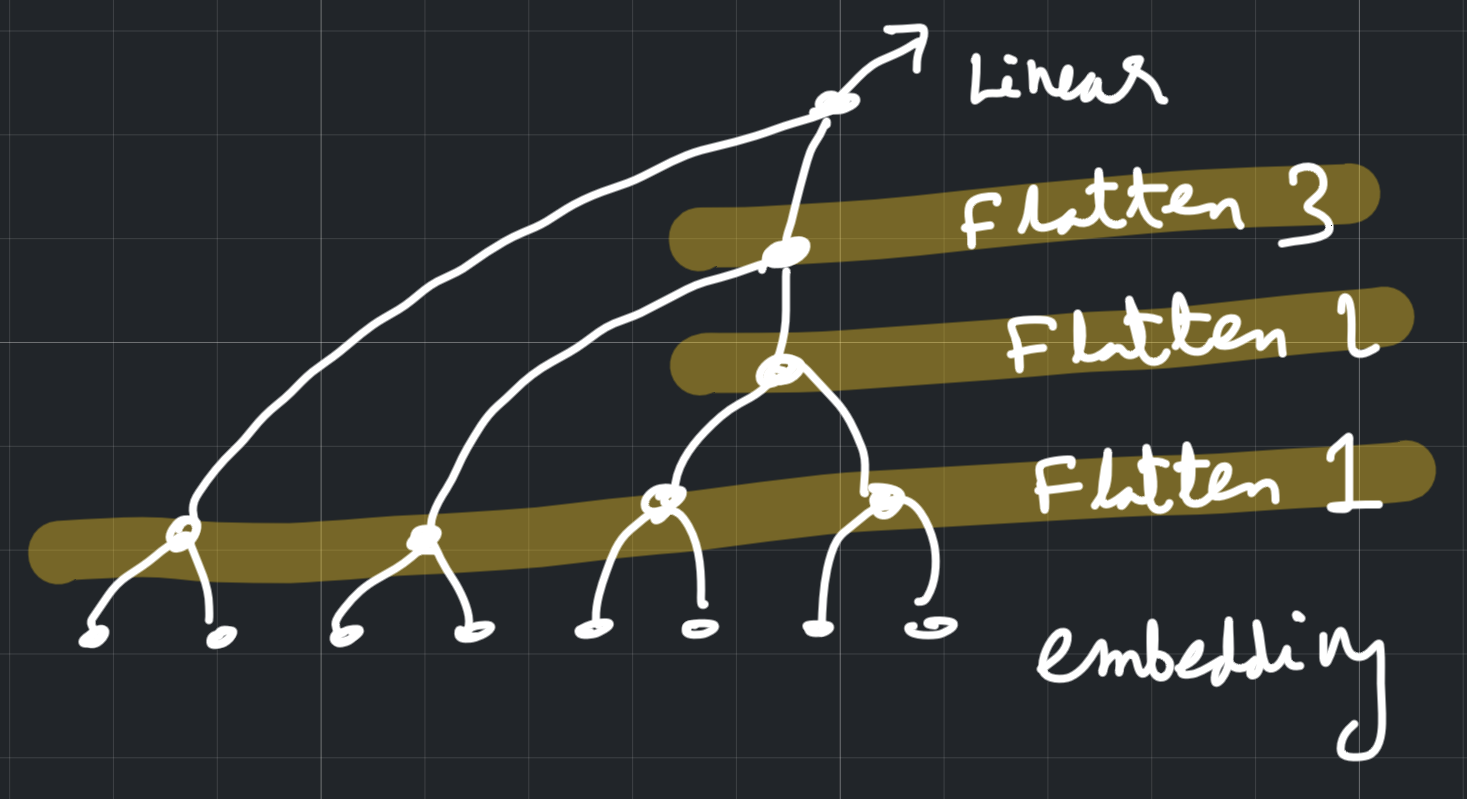

This is the model^

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  #NEW: Logits is the model's output instead of x = Xb (input is Xb only)
  #outputs of the model
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) #loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.5581
  10000/ 200000: 2.2173
  20000/ 200000: 2.4414
  30000/ 200000: 1.9835
  40000/ 200000: 1.7081
  50000/ 200000: 2.5048
  60000/ 200000: 2.0296
  70000/ 200000: 2.3292
  80000/ 200000: 2.0419
  90000/ 200000: 1.9631
 100000/ 200000: 1.9861
 110000/ 200000: 1.9557
 120000/ 200000: 1.9395
 130000/ 200000: 2.1764
 140000/ 200000: 2.3098
 150000/ 200000: 1.8342
 160000/ 200000: 1.7838
 170000/ 200000: 2.0644
 180000/ 200000: 1.7139
 190000/ 200000: 1.8174


In [ ]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7298928499221802
val 1.9879015684127808


This worked with the 2 char batch norm we had earlier as well, but its not right

If we had 2d only batchnorm

it would receive (32,4,68)

In [ ]:
# what happens inside batchnorm 2D
# it receives (32,4,68)
e = torch.randn(32,4,68)
#then it takes the mean, just the 32 nums in dim 1
emean = e.mean(0, keepdim=True) #1, 4, 68
# then var
evar = e.var(0, keepdim=True) #1, 4, 68
ehat = (e-emean) / torch.sqrt(evar + 1e-5) #32,4,68
ehat.shape

torch.Size([32, 4, 68])

But the running mean's shape would be 1,4,68 instead of being just 68 (n_hidden is 68, we would want each channel to have a running mean)

We are maintining running means for each of the 4

So, we dont want to avg over 32 nums, we want to avg over 32*4 nums for every one of these 68 channels

In [ ]:
# We can pass a tuple to torch.mean as well

# it receives (32,4,68)
e = torch.randn(32,4,68)
#then it takes the mean, 0,1
emean = e.mean((0,1), keepdim=True) #1, 1, 68
# then var, 0,1
evar = e.var((0,1), keepdim=True) #1, 1, 68
ehat = (e-emean) / torch.sqrt(evar + 1e-5) #32,4,68
ehat.shape

torch.Size([32, 4, 68])

same output, but here

In [ ]:
emean.shape

torch.Size([1, 1, 68])

A bit of a hint on convolutional NNs

In [ ]:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .


8 egs

In [ ]:
Xtr[7].shape

torch.Size([3])

Its just 3, you cant call the model on this

In [ ]:
# so we do this
Xtr[[7]].shape

torch.Size([1, 3])

We can call the model on this

In [ ]:
# forward a single example:
logits = model(Xtr[[7]])
logits.shape

/tmp/ipython-input-103932102.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  xvar = x.var(dim, keepdim=True) # batch variance


torch.Size([1, 27])

In [ ]:
# forward all 8 egs of them
logits = torch.zeros(8, 27)
for i in range(8):
  logits[i] = model(Xtr[[7+i]])
  print(i, Xtr[[7+i]])
  print("----")
print(f"Shape of logits: {logits.shape}")

0 tensor([[0, 0, 0, 0, 0, 0, 0, 0]])
----
1 tensor([[0, 0, 0, 0, 0, 0, 0, 4]])
----
2 tensor([[0, 0, 0, 0, 0, 0, 4, 9]])
----
3 tensor([[ 0,  0,  0,  0,  0,  4,  9, 15]])
----
4 tensor([[ 0,  0,  0,  0,  4,  9, 15, 14]])
----
5 tensor([[ 0,  0,  0,  4,  9, 15, 14,  4]])
----
6 tensor([[ 0,  0,  4,  9, 15, 14,  4, 18]])
----
7 tensor([[ 0,  4,  9, 15, 14,  4, 18,  5]])
----
Shape of logits: torch.Size([8, 27])


/tmp/ipython-input-103932102.py:39: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  xvar = x.var(dim, keepdim=True) # batch variance


So, convolution is a for loop applying a linear filter over space of some input sequence

The kernels do this, not a python for loop

In our case, we are interested in a 1d space and we're sliding these filters over input data

In [ ]:
# convolution is a "for loop"
# allows us to forward Linear layers efficiently over space